# Q5. Gradient Descent from Scratch Advertising dataset (TV, Radio, Newspaper → Sales)।
1. Gradient বের করার formula implement করো: dw = (1/m) * X.T @ (y_pred - y)
2. Learning rate 0.01 দিয়ে ১০০০ iteration চালাও
3. প্রতি ১০০ iteration এ cost print করো
4. Cost vs Iteration curve plot করো এবং কোথায় converge করেছে সেটা দেখাও


In [78]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\Advertising.csv")
df

<>:1: SyntaxWarning: invalid escape sequence '\J'
<>:1: SyntaxWarning: invalid escape sequence '\J'
C:\Users\HP\AppData\Local\Temp\ipykernel_8672\2149178013.py:1: SyntaxWarning: invalid escape sequence '\J'
  df = pd.read_csv("F:\Jupyter Projects\Phitron AL ML\Dataset\Advertising.csv")


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
...,...,...,...,...,...
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5


In [80]:
df.drop(columns='Unnamed: 0', inplace=True, axis = 1)

In [81]:
df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


In [82]:
df.isnull().sum()

TV           0
radio        0
newspaper    0
sales        0
dtype: int64

In [83]:
df['TV'] = (df['TV'] - df['TV'].min()) / (df['TV'].max() - df['TV'].min())
df

,TV,radio,newspaper,sales
0,0.775786,37.8,69.2,22.1
1,0.148123,39.3,45.1,10.4
2,0.055800,45.9,69.3,9.3
3,0.509976,41.3,58.5,18.5
4,0.609063,10.8,58.4,12.9
...,...,...,...,...
195,0.126818,3.7,13.8,7.6
196,0.316199,4.9,8.1,9.7
197,0.596212,9.3,6.4,12.8
198,0.956713,42.0,66.2,25.5


In [84]:
df['radio'] = (df['radio'] - df['radio'].min()) / (df['radio'].max() - df['radio'].min())
df

,TV,radio,newspaper,sales
0,0.775786,0.762097,69.2,22.1
1,0.148123,0.792339,45.1,10.4
2,0.055800,0.925403,69.3,9.3
3,0.509976,0.832661,58.5,18.5
4,0.609063,0.217742,58.4,12.9
...,...,...,...,...
195,0.126818,0.074597,13.8,7.6
196,0.316199,0.098790,8.1,9.7
197,0.596212,0.187500,6.4,12.8
198,0.956713,0.846774,66.2,25.5


In [85]:
df['newspaper'] = (df['newspaper'] - df['newspaper'].min()) / (df['newspaper'].max() - df['newspaper'].min())
df

,TV,radio,newspaper,sales
0,0.775786,0.762097,0.605981,22.1
1,0.148123,0.792339,0.394019,10.4
2,0.055800,0.925403,0.606860,9.3
3,0.509976,0.832661,0.511873,18.5
4,0.609063,0.217742,0.510994,12.9
...,...,...,...,...
195,0.126818,0.074597,0.118734,7.6
196,0.316199,0.098790,0.068602,9.7
197,0.596212,0.187500,0.053650,12.8
198,0.956713,0.846774,0.579595,25.5


In [86]:
X = df.drop(columns = 'sales', axis = 1)
y = df['sales']

In [87]:
X

,TV,radio,newspaper
0,0.775786,0.762097,0.605981
1,0.148123,0.792339,0.394019
2,0.055800,0.925403,0.606860
3,0.509976,0.832661,0.511873
4,0.609063,0.217742,0.510994
...,...,...,...
195,0.126818,0.074597,0.118734
196,0.316199,0.098790,0.068602
197,0.596212,0.187500,0.053650
198,0.956713,0.846774,0.579595


In [88]:
y

0      22.1
1      10.4
2       9.3
3      18.5
4      12.9
       ... 
195     7.6
196     9.7
197    12.8
198    25.5
199    13.4
Name: sales, Length: 200, dtype: float64

In [89]:
X = X.values

Text(0.5, 0, 'TV')

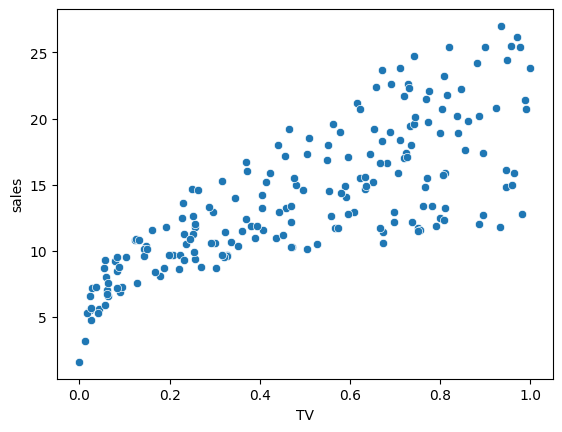

In [90]:
sns.scatterplot(x=X[:,0:1].ravel(),y=y)
plt.xlabel('TV')

Text(0.5, 0, 'Radio')

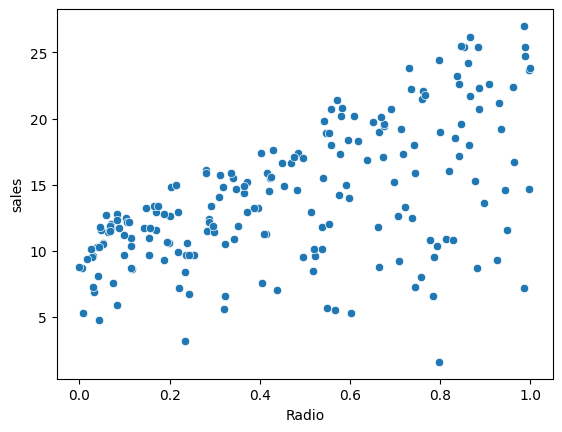

In [91]:
sns.scatterplot(x=X[:,1:2].ravel(),y=y)
plt.xlabel('Radio')

Text(0.5, 0, 'Newspaper')

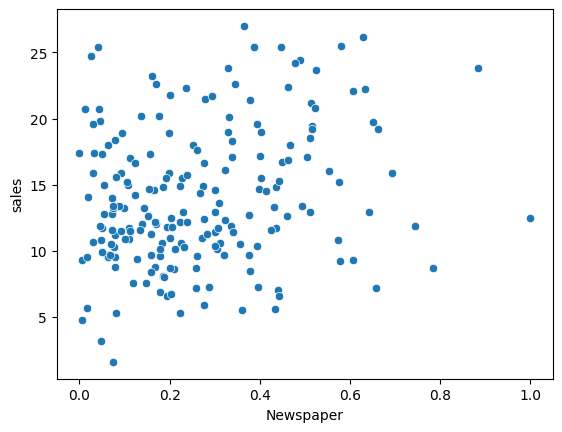

In [92]:
sns.scatterplot(x=X[:,2:3].ravel(),y=y)
plt.xlabel('Newspaper')

In [93]:
def make_prediction(X, w, b):
    return X @ w + b 

m = X.shape[0]
n = X.shape[1]

W_in = np.ones((n,))
b_in = 1.0

make_prediction(X,W_in,b_in)

array([3.14386369, 2.33448116, 2.58806318, 2.85451097, 2.33779902,
       2.66993363, 2.05742263, 1.89867144, 1.07521153, 1.90955397,
       1.54830788, 2.2401192 , 2.36273791, 1.54127063, 2.75310068,
       3.08275209, 2.9648224 , 3.23578666, 1.8032715 , 2.14297499,
       2.76170535, 2.10734177, 1.79643428, 2.33821726, 1.62066285,
       2.12613945, 2.17979802, 2.34506657, 2.5841657 , 1.9151694 ,
       2.9360369 , 2.06709644, 1.61779992, 2.29906619, 1.4119424 ,
       2.13550461, 2.82463809, 2.64551777, 1.98776362, 2.80756899,
       2.40733104, 2.60733034, 2.5621913 , 2.09623466, 1.97884944,
       2.31782231, 1.81192314, 2.80569188, 2.52076313, 1.78078287,
       2.03748862, 1.55973818, 2.91582777, 3.06023447, 2.60388147,
       3.19130763, 1.95032975, 1.98869119, 3.03945321, 2.38409297,
       1.40445801, 3.22063778, 2.3568659 , 2.0129585 , 2.55542985,
       1.42375439, 1.61683801, 1.84812825, 2.44901624, 2.85247641,
       2.62561664, 1.93342682, 1.92069413, 1.82280509, 2.32785

In [94]:
def cost_compute(X, y, W, b):
    return (1 / (2*m)) * np.sum(((make_prediction(X,W,b) - y) ** 2))

In [95]:
cost = cost_compute(X, y, W_in, b_in)
cost

80.90554589414982

In [96]:
import numpy as np

def calculate_gradient(X, y, W, b):
    m = X.shape[0]
    n = X.shape[1]

    dj_dw = np.zeros((n,))
    dj_db = 0.0

    for i in range(m):
        error = make_prediction(X[i], W, b) - y[i]
        dj_db += error

        for j in range(n):
            dj_dw[j] = dj_dw[j] + (error * X[i, j])
    
    return dj_dw / m, dj_db / m


In [97]:
def gradient_descent(X, y, W_in, b_in, max_iter, alpha = 0.01):
    W = W_in
    b = b_in

    cost_memo = []
    iteration = []
    for i in range(max_iter):
        dj_dw , dj_db = calculate_gradient(X,y,W,b)

        W = W - alpha * dj_dw
        b = b - alpha * dj_db

        cost = cost_compute(X, y, W, b)
        cost_memo.append(cost)
        iteration.append(i)

        if i % 100 == 0:
            print(f"Iteration {i}: Cost {cost:0.4f},dj_dw: {dj_dw} ,dj_db : {dj_db} w: {W}, b: {b:0.4f}")
    return W, b, cost_memo, iteration

In [98]:
W_init = np.zeros((n,))
b_init = 0.0

w_final, b_final, cost_memo, iter_list = gradient_descent(X, y, W_init, b_init, 1000, alpha=0.01)

Iteration 0: Cost 108.5438,dj_dw: [-8.11878914 -7.47241835 -3.95820932] ,dj_db : -14.022500000000003 w: [0.08118789 0.07472418 0.03958209], b: 0.1402
Iteration 100: Cost 9.5031,dj_dw: [-2.07391197 -1.70668322 -0.75420614] ,dj_db : -2.5977019539399153 w: [4.38576993 3.90633633 1.97357798], b: 6.9432
Iteration 200: Cost 4.9160,dj_dw: [-0.80675724 -0.51440369 -0.09793983] ,dj_db : -0.2673819201149359 w: [5.66318503 4.86111046 2.3129333 ], b: 8.0663
Iteration 300: Cost 4.3619,dj_dw: [-0.52270568 -0.26196213  0.03503658] ,dj_db : 0.1956165203422585 w: [6.29419943 5.21723066 2.32658725], b: 8.0387
Iteration 400: Cost 4.0194,dj_dw: [-0.44211864 -0.20289242  0.06060117] ,dj_db : 0.2759236421158231 w: [6.7694527  5.44301051 2.27512802], b: 7.7901
Iteration 500: Cost 3.7224,dj_dw: [-0.40473658 -0.18383999  0.06418186] ,dj_db : 0.2784767320759654 w: [7.19119215 5.63495246 2.21200359], b: 7.5104
Iteration 600: Cost 3.4597,dj_dw: [-0.37754637 -0.17329363  0.06332226] ,dj_db : 0.26586988003486905 w:

In [99]:
w_final

array([8.90899167, 6.44047359, 1.90939613])

In [100]:
b_final

6.293589748126743

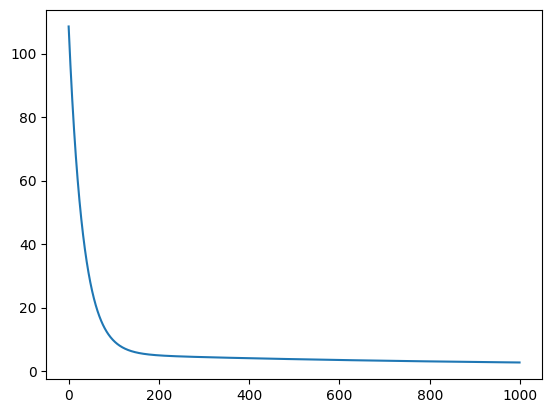

In [101]:
plt.plot(iter_list,cost_memo)